```LAB 1 - PART B```


*Aim*: To design and implement a Fuzzy Q-Learning agent that learns to balance a pole in the Cartpole-v1 environment by combining Fuzzy state representation with Q-learning.

*Task* :

1.  Convert continuous states into fuzzy linguistic variables. ( Try for 2 and 5 fuzzy sets)
2. Construct Fuzzy Rules/states
3. Apply Q-learning to fuzzy states
4. Develop an e-greedy fuzzy q-learning agent
5. Compare triangular and trapezoidal membership functions based Learning. 
6. Compare for Learning Rate = 0.01 ,0.1 and 0.05 
7. Compare for discount factor = 0.5 and 0.9

In [1]:
!pip install gymnasium[classic-control] scikit-fuzzy matplotlib pandas numpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/953.9 kB ? eta -:--:--
   ---------------------------------------- 953.9/953.9 kB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/920.8 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/920.8 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/920.8 kB ? eta -:--:--
   ---------------------------------------- 920.8/920.8 kB 1.1 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.7 MB 3.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.7 MB 4.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import skfuzzy as fuzz

from collections import defaultdict

In [3]:
#creating the fuzzy q learning agent

class FuzzyQLearningAgent:

    def __init__(
        self,
        n_fuzzy_sets=3,
        membership_type="triangular",
        learning_rate=0.1,
        discount_factor=0.9,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995
    ):

        # Number of fuzzy sets
        self.n_fuzzy_sets = n_fuzzy_sets

        # Membership function type
        self.membership_type = membership_type

        # Q-learning parameters
        self.alpha = learning_rate
        self.gamma = discount_factor

        # Epsilon-greedy parameters
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # CartPole has two actions:
        # 0 = Move Left
        # 1 = Move Right
        self.n_actions = 2

        # Define fuzzy membership functions
        self.create_membership_functions()

        # Q-table
        self.q_table = defaultdict(
            lambda: np.zeros(self.n_actions)
        )

In [13]:
#create membership functions for fuzzy sets

def create_membership_functions(self):

        """
        Creates fuzzy membership functions.

        We use normalized values from -1 to +1.
        """

        self.x = np.linspace(-1, 1, 1000)

        if self.n_fuzzy_sets == 2:

            # Two fuzzy sets:
            # Negative and Positive

            self.labels = ["Negative", "Positive"]

            if self.membership_type == "triangular":

                self.memberships = {
                    "Negative": fuzz.trimf(
                        self.x, [-1, -1, 0]
                    ),

                    "Positive": fuzz.trimf(
                        self.x, [0, 1, 1]
                    )
                }

            else:

                self.memberships = {
                    "Negative": fuzz.trapmf(
                        self.x, [-1, -1, -0.5, 0]
                    ),

                    "Positive": fuzz.trapmf(
                        self.x, [0, 0.5, 1, 1]
                    )
                }

        elif self.n_fuzzy_sets == 5:

            # Five fuzzy sets

            self.labels = [
                "Very Negative",
                "Negative",
                "Zero",
                "Positive",
                "Very Positive"
            ]

            if self.membership_type == "triangular":

                self.memberships = {

                    "Very Negative":
                        fuzz.trimf(
                            self.x,
                            [-1, -1, -0.5]
                        ),

                    "Negative":
                        fuzz.trimf(
                            self.x,
                            [-1, -0.5, 0]
                        ),

                    "Zero":
                        fuzz.trimf(
                            self.x,
                            [-0.5, 0, 0.5]
                        ),

                    "Positive":
                        fuzz.trimf(
                            self.x,
                            [0, 0.5, 1]
                        ),

                    "Very Positive":
                        fuzz.trimf(
                            self.x,
                            [0.5, 1, 1]
                        )
                }

            else:

                self.memberships = {

                    "Very Negative":
                        fuzz.trapmf(
                            self.x,
                            [-1, -1, -0.75, -0.5]
                        ),

                    "Negative":
                        fuzz.trapmf(
                            self.x,
                            [-0.75, -0.5, -0.25, 0]
                        ),

                    "Zero":
                        fuzz.trapmf(
                            self.x,
                            [-0.25, -0.1, 0.1, 0.25]
                        ),

                    "Positive":
                        fuzz.trapmf(
                            self.x,
                            [0, 0.25, 0.5, 0.75]
                        ),

                    "Very Positive":
                        fuzz.trapmf(
                            self.x,
                            [0.5, 0.75, 1, 1]
                        )
                }

        else:

            raise ValueError(
                "Only 2 or 5 fuzzy sets are supported."
            )

In [14]:
#plot
def plot_membership_functions(agent):

    plt.figure(figsize=(10, 5))

    for label, membership in agent.memberships.items():

        plt.plot(
            agent.x,
            membership,
            label=label
        )

    plt.xlabel("Normalized State Value")
    plt.ylabel("Membership Degree")
    plt.title(
        f"{agent.membership_type.title()} Membership Functions "
        f"({agent.n_fuzzy_sets} Sets)"
    )

    plt.legend()
    plt.grid()
    plt.show()

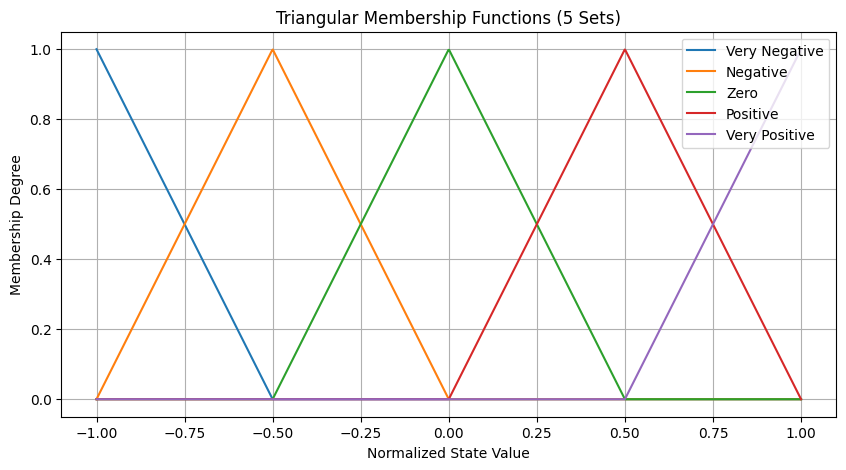

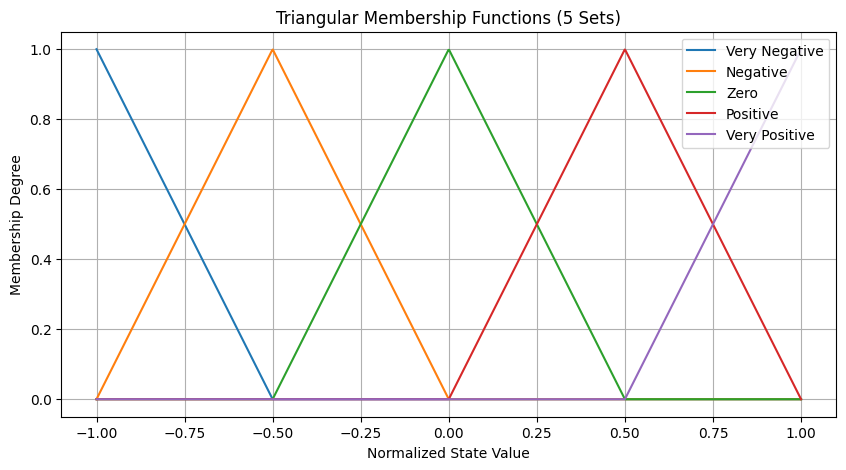

In [16]:
# Bind the standalone function as a method on the class
FuzzyQLearningAgent.create_membership_functions = create_membership_functions

agent = FuzzyQLearningAgent(
    n_fuzzy_sets=5,
    membership_type="triangular"
)

plot_membership_functions(agent)

plot_membership_functions(agent)

In [17]:
#converting a continuous state to a fuzzy state representation

def get_fuzzy_label(self, value):

        # Keep value inside [-1, 1]
        value = np.clip(value, -1, 1)

        membership_values = {}

        for label, membership in self.memberships.items():

            degree = fuzz.interp_membership(
                self.x,
                membership,
                value
            )

            membership_values[label] = degree

        # Select fuzzy set with highest membership
        best_label = max(
            membership_values,
            key=membership_values.get
        )

        return self.labels.index(best_label)

In [19]:
#normalize the cartpole state

def normalize_state(self, state):

        position = state[0]
        velocity = state[1]
        angle = state[2]
        angular_velocity = state[3]

        # Approximate useful ranges for CartPole

        position = np.clip(
            position / 2.4,
            -1,
            1
        )

        velocity = np.clip(
            velocity / 3.0,
            -1,
            1
        )

        angle = np.clip(
            angle / 0.2095,
            -1,
            1
        )

        angular_velocity = np.clip(
            angular_velocity / 3.5,
            -1,
            1
        )

        return [
            position,
            velocity,
            angle,
            angular_velocity
        ]

In [20]:
#Convert complete state to fuzzy state

def get_fuzzy_state(self, state):

        normalized_state = self.normalize_state(state)

        fuzzy_state = tuple(
            self.get_fuzzy_label(value)
            for value in normalized_state
        )

        return fuzzy_state

In [21]:
#epsilon-greedy action selection

def choose_action(self, state):

        fuzzy_state = self.get_fuzzy_state(state)

        # Exploration
        if np.random.random() < self.epsilon:

            action = np.random.randint(
                self.n_actions
            )

        # Exploitation
        else:

            action = np.argmax(
                self.q_table[fuzzy_state]
            )

        return action

In [22]:
#q learning update 

def update(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        current_fuzzy_state = self.get_fuzzy_state(
            state
        )

        next_fuzzy_state = self.get_fuzzy_state(
            next_state
        )

        current_q = self.q_table[
            current_fuzzy_state
        ][action]

        if done:

            target = reward

        else:

            future_q = np.max(
                self.q_table[next_fuzzy_state]
            )

            target = reward + self.gamma * future_q

        # Q-learning update
        self.q_table[
            current_fuzzy_state
        ][action] += self.alpha * (
            target - current_q
        )

In [23]:
#epsilon decay

def decay_epsilon(self):

        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay
        )

In [24]:
#training the agent 

def train_agent(
    n_fuzzy_sets=5,
    membership_type="triangular",
    learning_rate=0.1,
    discount_factor=0.9,
    episodes=500
):

    env = gym.make("CartPole-v1")

    agent = FuzzyQLearningAgent(
        n_fuzzy_sets=n_fuzzy_sets,
        membership_type=membership_type,
        learning_rate=learning_rate,
        discount_factor=discount_factor
    )

    rewards = []

    for episode in range(episodes):

        state, info = env.reset()

        total_reward = 0

        for step in range(500):

            # Choose action using epsilon-greedy
            action = agent.choose_action(state)

            # Perform action
            next_state, reward, terminated, truncated, info = \
                env.step(action)

            done = terminated or truncated

            # Update Q-table
            agent.update(
                state,
                action,
                reward,
                next_state,
                done
            )

            state = next_state

            total_reward += reward

            if done:
                break

        # Reduce exploration
        agent.decay_epsilon()

        rewards.append(total_reward)

        if (episode + 1) % 50 == 0:

            print(
                f"Episode {episode + 1}/{episodes} "
                f"| Reward: {total_reward:.1f} "
                f"| Epsilon: {agent.epsilon:.3f}"
            )

    env.close()

    return agent, rewards

In [28]:
#plotting the learning curve

def plot_learning_curve(rewards, title):

    plt.figure(figsize=(10, 5))

    plt.plot(
        rewards,
        alpha=0.3,
        label="Episode Reward"
    )

    # Rolling average
    window = 50

    if len(rewards) >= window:

        rolling_average = np.convolve(
            rewards,
            np.ones(window) / window,
            mode="valid"
        )

        plt.plot(
            range(
                window - 1,
                len(rewards)
            ),
            rolling_average,
            label="50-Episode Average"
        )

    plt.xlabel("Episode")
    plt.ylabel("Reward")

    plt.title(title)

    plt.legend()
    plt.grid()

    plt.show()
    plot_learning_curve(
    rewards,
    "Fuzzy Q-Learning - Triangular - 5 Sets"
)

In [29]:
#evaluation 

def evaluate_agent(agent, episodes=100):

    env = gym.make("CartPole-v1")

    evaluation_rewards = []

    old_epsilon = agent.epsilon

    # Turn off exploration
    agent.epsilon = 0

    for episode in range(episodes):

        state, info = env.reset()

        total_reward = 0

        for step in range(500):

            action = agent.choose_action(state)

            next_state, reward, terminated, truncated, info = \
                env.step(action)

            total_reward += reward

            state = next_state

            if terminated or truncated:
                break

        evaluation_rewards.append(
            total_reward
        )

    # Restore epsilon
    agent.epsilon = old_epsilon

    env.close()

    return evaluation_rewards

In [33]:
def evaluate_agent(agent, episodes=100):

    env = gym.make("CartPole-v1")

    evaluation_rewards = []

    old_epsilon = agent.epsilon

    # Turn off exploration
    agent.epsilon = 0

    for episode in range(episodes):

        state, info = env.reset()

        total_reward = 0

        for step in range(500):

            action = agent.choose_action(state)

            next_state, reward, terminated, truncated, info = \
                env.step(action)

            total_reward += reward

            state = next_state

            if terminated or truncated:
                break

        evaluation_rewards.append(
            total_reward
        )

    # Restore epsilon
    agent.epsilon = old_epsilon

    env.close()

    return evaluation_rewards

# Bind the standalone methods to the class so they work as instance methods
FuzzyQLearningAgent.get_fuzzy_label = get_fuzzy_label
FuzzyQLearningAgent.normalize_state = normalize_state
FuzzyQLearningAgent.get_fuzzy_state = get_fuzzy_state
FuzzyQLearningAgent.choose_action = choose_action
FuzzyQLearningAgent.update = update
FuzzyQLearningAgent.decay_epsilon = decay_epsilon

evaluation_rewards = evaluate_agent(
    agent,
    episodes=100
)

print(
    "Average Evaluation Reward:",
    np.mean(evaluation_rewards)
)

Average Evaluation Reward: 9.47


In [34]:
# Experiment 1: 2 vs 5 fuzzy sets

results_fuzzy_sets = {}

for fuzzy_sets in [2, 5]:

    agent, rewards = train_agent(
        n_fuzzy_sets=fuzzy_sets,
        membership_type="triangular",
        learning_rate=0.1,
        discount_factor=0.9,
        episodes=500
    )

    evaluation = evaluate_agent(
        agent,
        episodes=100
    )

    results_fuzzy_sets[fuzzy_sets] = {
        "training_rewards": rewards,
        "evaluation_rewards": evaluation
    }

Episode 50/500 | Reward: 11.0 | Epsilon: 0.778
Episode 100/500 | Reward: 16.0 | Epsilon: 0.606
Episode 150/500 | Reward: 38.0 | Epsilon: 0.471
Episode 200/500 | Reward: 57.0 | Epsilon: 0.367
Episode 250/500 | Reward: 38.0 | Epsilon: 0.286
Episode 300/500 | Reward: 17.0 | Epsilon: 0.222
Episode 350/500 | Reward: 45.0 | Epsilon: 0.173
Episode 400/500 | Reward: 18.0 | Epsilon: 0.135
Episode 450/500 | Reward: 178.0 | Epsilon: 0.105
Episode 500/500 | Reward: 16.0 | Epsilon: 0.082
Episode 50/500 | Reward: 61.0 | Epsilon: 0.778
Episode 100/500 | Reward: 19.0 | Epsilon: 0.606
Episode 150/500 | Reward: 21.0 | Epsilon: 0.471
Episode 200/500 | Reward: 17.0 | Epsilon: 0.367
Episode 250/500 | Reward: 19.0 | Epsilon: 0.286
Episode 300/500 | Reward: 30.0 | Epsilon: 0.222
Episode 350/500 | Reward: 12.0 | Epsilon: 0.173
Episode 400/500 | Reward: 33.0 | Epsilon: 0.135
Episode 450/500 | Reward: 95.0 | Epsilon: 0.105
Episode 500/500 | Reward: 87.0 | Epsilon: 0.082


In [35]:
for fuzzy_sets, result in results_fuzzy_sets.items():

    print(
        f"{fuzzy_sets} fuzzy sets:"
    )

    print(
        "Average evaluation reward:",
        np.mean(result["evaluation_rewards"])
    )

    print()

2 fuzzy sets:
Average evaluation reward: 54.31

5 fuzzy sets:
Average evaluation reward: 23.02



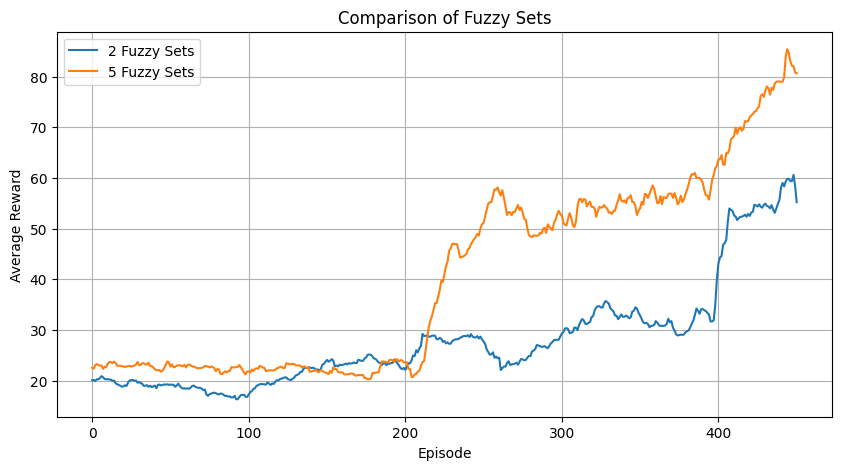

In [36]:
# Plot 2 vs 5 fuzzy sets

plt.figure(figsize=(10, 5))

for fuzzy_sets, result in results_fuzzy_sets.items():

    rewards = result["training_rewards"]

    window = 50

    rolling = np.convolve(
        rewards,
        np.ones(window) / window,
        mode="valid"
    )

    plt.plot(
        rolling,
        label=f"{fuzzy_sets} Fuzzy Sets"
    )

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Comparison of Fuzzy Sets")

plt.legend()
plt.grid()

plt.show()

In [37]:
#experiment 2: Triangular vs Trapezoidal

results_membership = {}

for membership in [
    "triangular",
    "trapezoidal"
]:

    agent, rewards = train_agent(
        n_fuzzy_sets=5,
        membership_type=membership,
        learning_rate=0.1,
        discount_factor=0.9,
        episodes=500
    )

    evaluation = evaluate_agent(
        agent,
        episodes=100
    )

    results_membership[membership] = {
        "training_rewards": rewards,
        "evaluation_rewards": evaluation
    }

Episode 50/500 | Reward: 31.0 | Epsilon: 0.778
Episode 100/500 | Reward: 14.0 | Epsilon: 0.606
Episode 150/500 | Reward: 11.0 | Epsilon: 0.471
Episode 200/500 | Reward: 13.0 | Epsilon: 0.367
Episode 250/500 | Reward: 16.0 | Epsilon: 0.286
Episode 300/500 | Reward: 44.0 | Epsilon: 0.222
Episode 350/500 | Reward: 87.0 | Epsilon: 0.173
Episode 400/500 | Reward: 138.0 | Epsilon: 0.135
Episode 450/500 | Reward: 101.0 | Epsilon: 0.105
Episode 500/500 | Reward: 98.0 | Epsilon: 0.082
Episode 50/500 | Reward: 14.0 | Epsilon: 0.778
Episode 100/500 | Reward: 11.0 | Epsilon: 0.606
Episode 150/500 | Reward: 54.0 | Epsilon: 0.471
Episode 200/500 | Reward: 56.0 | Epsilon: 0.367
Episode 250/500 | Reward: 35.0 | Epsilon: 0.286
Episode 300/500 | Reward: 92.0 | Epsilon: 0.222
Episode 350/500 | Reward: 17.0 | Epsilon: 0.173
Episode 400/500 | Reward: 129.0 | Epsilon: 0.135
Episode 450/500 | Reward: 63.0 | Epsilon: 0.105
Episode 500/500 | Reward: 80.0 | Epsilon: 0.082


In [39]:
for membership, result in results_membership.items():

    print(
        membership,
        "Average Reward:",
        np.mean(result["evaluation_rewards"])
    )

triangular Average Reward: 24.46
trapezoidal Average Reward: 36.45


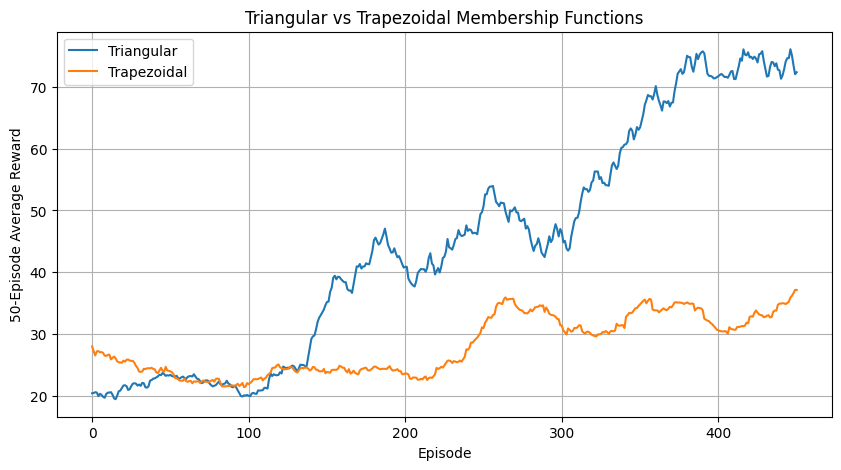

In [40]:
plt.figure(figsize=(10, 5))

for membership, result in results_membership.items():

    rewards = result["training_rewards"]

    rolling = np.convolve(
        rewards,
        np.ones(50) / 50,
        mode="valid"
    )

    plt.plot(
        rolling,
        label=membership.title()
    )

plt.xlabel("Episode")
plt.ylabel("50-Episode Average Reward")

plt.title(
    "Triangular vs Trapezoidal Membership Functions"
)

plt.legend()
plt.grid()

plt.show()

In [42]:
# Experiment 3: Learning rate

learning_rates = [0.01, 0.05, 0.1]

learning_rate_results = {}

for alpha in learning_rates:

    agent, rewards = train_agent(
        n_fuzzy_sets=5,
        membership_type="triangular",
        learning_rate=alpha,
        discount_factor=0.9,
        episodes=500
    )

    evaluation = evaluate_agent(
        agent,
        episodes=100
    )

    learning_rate_results[alpha] = {
        "training_rewards": rewards,
        "evaluation_rewards": evaluation
    }

Episode 50/500 | Reward: 11.0 | Epsilon: 0.778
Episode 100/500 | Reward: 12.0 | Epsilon: 0.606
Episode 150/500 | Reward: 27.0 | Epsilon: 0.471
Episode 200/500 | Reward: 61.0 | Epsilon: 0.367
Episode 250/500 | Reward: 31.0 | Epsilon: 0.286
Episode 300/500 | Reward: 16.0 | Epsilon: 0.222
Episode 350/500 | Reward: 12.0 | Epsilon: 0.173
Episode 400/500 | Reward: 40.0 | Epsilon: 0.135
Episode 450/500 | Reward: 19.0 | Epsilon: 0.105
Episode 500/500 | Reward: 16.0 | Epsilon: 0.082
Episode 50/500 | Reward: 27.0 | Epsilon: 0.778
Episode 100/500 | Reward: 22.0 | Epsilon: 0.606
Episode 150/500 | Reward: 58.0 | Epsilon: 0.471
Episode 200/500 | Reward: 15.0 | Epsilon: 0.367
Episode 250/500 | Reward: 13.0 | Epsilon: 0.286
Episode 300/500 | Reward: 80.0 | Epsilon: 0.222
Episode 350/500 | Reward: 21.0 | Epsilon: 0.173
Episode 400/500 | Reward: 11.0 | Epsilon: 0.135
Episode 450/500 | Reward: 68.0 | Epsilon: 0.105
Episode 500/500 | Reward: 94.0 | Epsilon: 0.082
Episode 50/500 | Reward: 51.0 | Epsilon: 0

In [43]:
for alpha, result in learning_rate_results.items():

    print(
        f"Learning Rate = {alpha}"
    )

    print(
        "Average Reward =",
        np.mean(result["evaluation_rewards"])
    )

    print()

Learning Rate = 0.01
Average Reward = 22.8

Learning Rate = 0.05
Average Reward = 86.98

Learning Rate = 0.1
Average Reward = 116.86



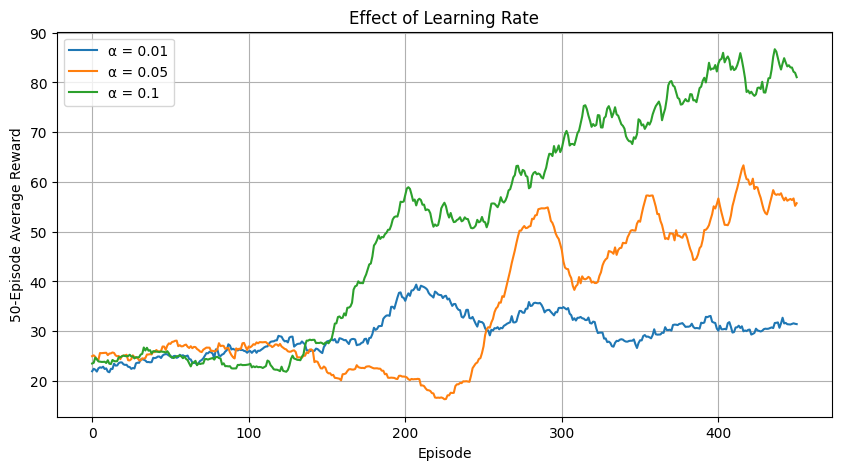

In [44]:
plt.figure(figsize=(10, 5))

for alpha, result in learning_rate_results.items():

    rewards = result["training_rewards"]

    rolling = np.convolve(
        rewards,
        np.ones(50) / 50,
        mode="valid"
    )

    plt.plot(
        rolling,
        label=f"α = {alpha}"
    )

plt.xlabel("Episode")
plt.ylabel("50-Episode Average Reward")

plt.title("Effect of Learning Rate")

plt.legend()
plt.grid()

plt.show()

In [45]:
# Experiment 4: Discount factor

discount_factors = [0.5, 0.9]

discount_results = {}

for gamma in discount_factors:

    agent, rewards = train_agent(
        n_fuzzy_sets=5,
        membership_type="triangular",
        learning_rate=0.1,
        discount_factor=gamma,
        episodes=500
    )

    evaluation = evaluate_agent(
        agent,
        episodes=100
    )

    discount_results[gamma] = {
        "training_rewards": rewards,
        "evaluation_rewards": evaluation
    }

Episode 50/500 | Reward: 32.0 | Epsilon: 0.778
Episode 100/500 | Reward: 14.0 | Epsilon: 0.606
Episode 150/500 | Reward: 12.0 | Epsilon: 0.471
Episode 200/500 | Reward: 17.0 | Epsilon: 0.367
Episode 250/500 | Reward: 13.0 | Epsilon: 0.286
Episode 300/500 | Reward: 12.0 | Epsilon: 0.222
Episode 350/500 | Reward: 11.0 | Epsilon: 0.173
Episode 400/500 | Reward: 13.0 | Epsilon: 0.135
Episode 450/500 | Reward: 12.0 | Epsilon: 0.105
Episode 500/500 | Reward: 12.0 | Epsilon: 0.082
Episode 50/500 | Reward: 10.0 | Epsilon: 0.778
Episode 100/500 | Reward: 14.0 | Epsilon: 0.606
Episode 150/500 | Reward: 15.0 | Epsilon: 0.471
Episode 200/500 | Reward: 27.0 | Epsilon: 0.367
Episode 250/500 | Reward: 38.0 | Epsilon: 0.286
Episode 300/500 | Reward: 82.0 | Epsilon: 0.222
Episode 350/500 | Reward: 65.0 | Epsilon: 0.173
Episode 400/500 | Reward: 79.0 | Epsilon: 0.135
Episode 450/500 | Reward: 84.0 | Epsilon: 0.105
Episode 500/500 | Reward: 113.0 | Epsilon: 0.082


In [46]:
for gamma, result in discount_results.items():

    print(
        f"Discount Factor = {gamma}"
    )

    print(
        "Average Reward =",
        np.mean(result["evaluation_rewards"])
    )

    print()

Discount Factor = 0.5
Average Reward = 24.05

Discount Factor = 0.9
Average Reward = 122.29



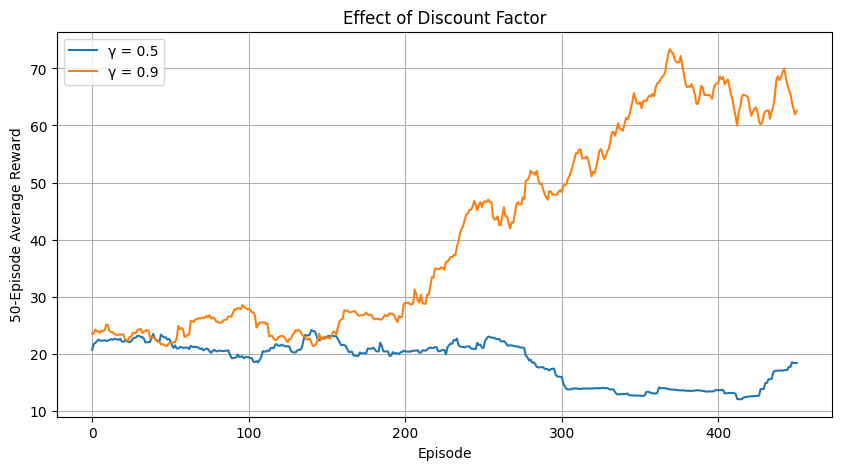

In [47]:
plt.figure(figsize=(10, 5))

for gamma, result in discount_results.items():

    rewards = result["training_rewards"]

    rolling = np.convolve(
        rewards,
        np.ones(50) / 50,
        mode="valid"
    )

    plt.plot(
        rolling,
        label=f"γ = {gamma}"
    )

plt.xlabel("Episode")
plt.ylabel("50-Episode Average Reward")

plt.title("Effect of Discount Factor")

plt.legend()
plt.grid()

plt.show()

In [48]:
# final comparison table 

results = []

configurations = [

    (2, "triangular", 0.1, 0.9),

    (5, "triangular", 0.1, 0.9),

    (5, "trapezoidal", 0.1, 0.9),

    (5, "triangular", 0.01, 0.9),

    (5, "triangular", 0.05, 0.9),

    (5, "triangular", 0.1, 0.9),

    (5, "triangular", 0.1, 0.5),

    (5, "triangular", 0.1, 0.9)
]


for fuzzy_sets, membership, alpha, gamma in configurations:

    agent, training_rewards = train_agent(

        n_fuzzy_sets=fuzzy_sets,

        membership_type=membership,

        learning_rate=alpha,

        discount_factor=gamma,

        episodes=500
    )

    evaluation_rewards = evaluate_agent(
        agent,
        episodes=100
    )

    results.append({

        "Fuzzy Sets": fuzzy_sets,

        "Membership": membership,

        "Learning Rate": alpha,

        "Discount Factor": gamma,

        "Average Evaluation Reward":
            np.mean(evaluation_rewards),

        "Std Evaluation Reward":
            np.std(evaluation_rewards)

    })


results_df = pd.DataFrame(results)

results_df

Episode 50/500 | Reward: 23.0 | Epsilon: 0.778
Episode 100/500 | Reward: 11.0 | Epsilon: 0.606
Episode 150/500 | Reward: 15.0 | Epsilon: 0.471
Episode 200/500 | Reward: 10.0 | Epsilon: 0.367
Episode 250/500 | Reward: 13.0 | Epsilon: 0.286
Episode 300/500 | Reward: 129.0 | Epsilon: 0.222
Episode 350/500 | Reward: 54.0 | Epsilon: 0.173
Episode 400/500 | Reward: 33.0 | Epsilon: 0.135
Episode 450/500 | Reward: 40.0 | Epsilon: 0.105
Episode 500/500 | Reward: 10.0 | Epsilon: 0.082
Episode 50/500 | Reward: 52.0 | Epsilon: 0.778
Episode 100/500 | Reward: 84.0 | Epsilon: 0.606
Episode 150/500 | Reward: 11.0 | Epsilon: 0.471
Episode 200/500 | Reward: 51.0 | Epsilon: 0.367
Episode 250/500 | Reward: 86.0 | Epsilon: 0.286
Episode 300/500 | Reward: 83.0 | Epsilon: 0.222
Episode 350/500 | Reward: 62.0 | Epsilon: 0.173
Episode 400/500 | Reward: 91.0 | Epsilon: 0.135
Episode 450/500 | Reward: 13.0 | Epsilon: 0.105
Episode 500/500 | Reward: 44.0 | Epsilon: 0.082
Episode 50/500 | Reward: 18.0 | Epsilon: 

,Fuzzy Sets,Membership,Learning Rate,Discount Factor,Average Evaluation Reward,Std Evaluation Reward
0,2,triangular,0.10,0.9,15.45,7.705031
1,5,triangular,0.10,0.9,103.67,9.183741
2,5,trapezoidal,0.10,0.9,42.34,16.990127
3,5,triangular,0.01,0.9,68.33,30.642799
4,5,triangular,0.05,0.9,84.12,11.110608
5,5,triangular,0.10,0.9,80.34,57.744475
6,5,triangular,0.10,0.5,13.56,1.663250
7,5,triangular,0.10,0.9,88.37,6.157361
